In [31]:
"""
🎯 Purpose:
Load all required libraries and configure device (CPU/GPU).

Why important?
- Enables deep learning with PyTorch
- Sets up GPU acceleration for faster training
- Imports tools for preprocessing, visualization, and evaluation
"""

import torch
import torch.nn as nn
import torch.optim as optim
import time
from tqdm import tqdm

from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from PIL import Image

torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Using device:", device)

✅ Using device: cuda


In [32]:
"""
🎯 Purpose:
Define preprocessing steps for training and validation images.

Why important?
- Resizes images for model compatibility
- Applies augmentation to improve generalization
- Normalizes images for better model performance
"""

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

print("✅ Transformations defined")

✅ Transformations defined


In [33]:
"""
🎯 Purpose:
Load dataset and split into train, validation, and test sets (70/15/15).

Why important?
- Ensures proper evaluation of model
- Prevents overfitting
- Maintains class balance using stratified split
"""

data_dir = "../data/chest_xray/train"

full_dataset = datasets.ImageFolder(data_dir)

file_paths = [x[0] for x in full_dataset.samples]
labels = [x[1] for x in full_dataset.samples]

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    file_paths, labels, test_size=0.3, stratify=labels, random_state=42
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

print(f"✅ Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

✅ Train: 3651 | Val: 782 | Test: 783


In [34]:
"""
🎯 Purpose:
Create a custom dataset class for loading images and labels.

Why important?
- Allows flexible data loading
- Applies transformations dynamically
- Compatible with PyTorch DataLoader
"""

class CustomDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        image = Image.open(self.file_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

print("✅ Custom dataset ready")

✅ Custom dataset ready


In [35]:
"""
🎯 Purpose:
Create DataLoaders for batch processing.

Why important?
- Enables efficient data loading
- Supports batching and shuffling
- Improves training performance
"""

train_dataset = CustomDataset(train_paths, train_labels, train_transform)
val_dataset   = CustomDataset(val_paths, val_labels, val_transform)
test_dataset  = CustomDataset(test_paths, test_labels, val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=32, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=32, num_workers=0, pin_memory=True)

print("✅ DataLoaders created")

✅ DataLoaders created


In [36]:
"""
🎯 Purpose:
Load pretrained ResNet18 model and modify final layer.

Why important?
- Uses transfer learning
- Adapts model for binary classification
- Dropout improves generalization
"""

model = resnet18(weights=ResNet18_Weights.DEFAULT)

num_features = model.fc.in_features

model.fc = nn.Sequential(   # type: ignore
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 2)
)

model = model.to(device)

print("✅ Model ready")

✅ Model ready


In [37]:
"""
🎯 Purpose:
Define loss function.

Why important?
- Measures prediction error
- Guides model learning during training
"""

criterion = nn.CrossEntropyLoss()
print("✅ Loss function defined")

✅ Loss function defined


In [38]:
"""
🎯 Purpose:
Create necessary folders for saving models and outputs.

Why important?
- Prevents file saving errors
- Keeps project organized
"""

import os

os.makedirs("../models", exist_ok=True)
os.makedirs("../outputs/graphs", exist_ok=True)

print("✅ Folders ready")

✅ Folders ready


In [39]:
"""
🎯 Purpose:
Train model and evaluate on validation set.

Why important?
- Updates model weights using backpropagation
- Tracks training and validation performance
- Displays progress using tqdm and Keras-style output
"""

def train_model(model, optimizer, epochs):
    
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0
    
    for epoch in range(epochs):
        start_time = time.time()

        print(f"\n🔥 Epoch [{epoch+1}/{epochs}]")

        model.train()
        train_loss, correct, total = 0, 0, 0
        
        loop = tqdm(train_loader, leave=False)

        for images, labels in loop:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # 🔥 Live batch update
            loop.set_postfix(
                loss=f"{loss.item():.4f}",
                acc=f"{100 * correct / total:.2f}%"
            )

        train_loss /= len(train_loader)
        train_acc = 100 * correct / total

        model.eval()
        val_loss, correct, total = 0, 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = 100 * correct / total
        
         # 🔥 SAVE BEST MODEL
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "../models/best_model.pth")
            print("✅ Best model saved!")
            
        end_time = time.time()

        # 🔥 KERAS-STYLE OUTPUT
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"{len(train_loader)}/{len(train_loader)} "
              f"- {end_time - start_time:.0f}s "
              f"- loss: {train_loss:.4f} "
              f"- accuracy: {train_acc:.2f}% "
              f"- val_loss: {val_loss:.4f} "
              f"- val_accuracy: {val_acc:.2f}%")

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

    return train_losses, val_losses, train_accs, val_accs

In [40]:
"""
🎯 Purpose:
Train only the final layer of the pretrained model (feature extraction phase).

Why important?
- Uses pretrained features from ImageNet
- Faster training
- Helps model adapt to new dataset initially
"""

print("🔵 Phase 1: Feature Extraction")

for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

train_losses, val_losses, train_accs, val_accs = train_model(model, optimizer, epochs=5)

🔵 Phase 1: Feature Extraction

🔥 Epoch [1/5]


✅ Best model saved!

Epoch 1/5
115/115 - 125s - loss: 0.2748 - accuracy: 87.89% - val_loss: 0.1599 - val_accuracy: 93.86%

🔥 Epoch [2/5]



Epoch 2/5
115/115 - 145s - loss: 0.1887 - accuracy: 92.11% - val_loss: 0.1702 - val_accuracy: 93.35%

🔥 Epoch [3/5]


✅ Best model saved!

Epoch 3/5
115/115 - 158s - loss: 0.2053 - accuracy: 91.76% - val_loss: 0.1364 - val_accuracy: 94.76%

🔥 Epoch [4/5]


✅ Best model saved!

Epoch 4/5
115/115 - 196s - loss: 0.1775 - accuracy: 93.34% - val_loss: 0.1275 - val_accuracy: 95.27%

🔥 Epoch [5/5]



Epoch 5/5
115/115 - 179s - loss: 0.1612 - accuracy: 93.67% - val_loss: 0.1680 - val_accuracy: 93.61%


In [41]:
"""
🎯 Purpose:
Fine-tune deeper layers of the model to improve performance.

Why important?
- Allows model to learn dataset-specific features
- Improves accuracy significantly
- Makes model more robust
"""

print("🟢 Phase 2: Fine-Tuning")

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=0.0001)

ft_train_losses, ft_val_losses, ft_train_accs, ft_val_accs = train_model(model, optimizer, epochs=5)

🟢 Phase 2: Fine-Tuning

🔥 Epoch [1/5]


✅ Best model saved!

Epoch 1/5
115/115 - 143s - loss: 0.1291 - accuracy: 95.26% - val_loss: 0.0677 - val_accuracy: 97.19%

🔥 Epoch [2/5]


✅ Best model saved!

Epoch 2/5
115/115 - 166s - loss: 0.0731 - accuracy: 97.21% - val_loss: 0.0456 - val_accuracy: 98.47%

🔥 Epoch [3/5]



Epoch 3/5
115/115 - 167s - loss: 0.0602 - accuracy: 97.75% - val_loss: 0.0467 - val_accuracy: 98.08%

🔥 Epoch [4/5]


✅ Best model saved!

Epoch 4/5
115/115 - 153s - loss: 0.0627 - accuracy: 97.64% - val_loss: 0.0302 - val_accuracy: 99.10%

🔥 Epoch [5/5]



Epoch 5/5
115/115 - 167s - loss: 0.0334 - accuracy: 98.74% - val_loss: 0.0242 - val_accuracy: 99.10%


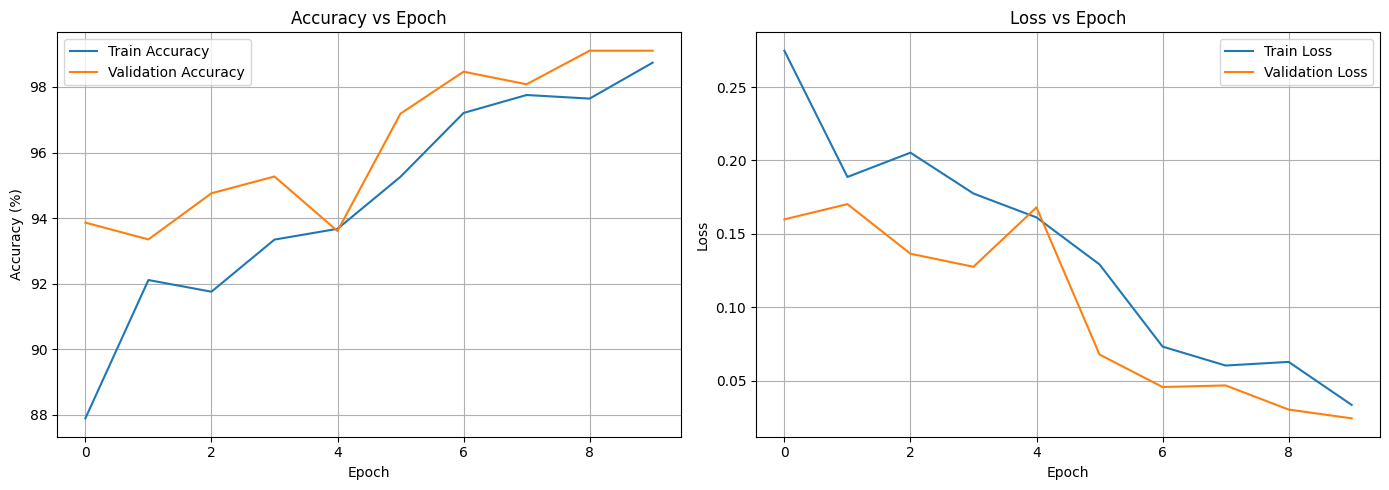

In [42]:
"""
🎯 Purpose:
Visualize training and validation performance.

Why important?
- Helps analyze model learning
- Detects overfitting or underfitting
- Shows convergence behavior
"""

import os
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

os.makedirs("../outputs/graphs", exist_ok=True)

all_train_accs   = train_accs + ft_train_accs
all_val_accs     = val_accs   + ft_val_accs

all_train_losses = train_losses + ft_train_losses
all_val_losses   = val_losses   + ft_val_losses

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(all_train_accs, label="Train Accuracy")
plt.plot(all_val_accs, label="Validation Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(all_train_losses, label="Train Loss")
plt.plot(all_val_losses, label="Validation Loss")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig("../outputs/graphs/training_analysis.png")
plt.show()

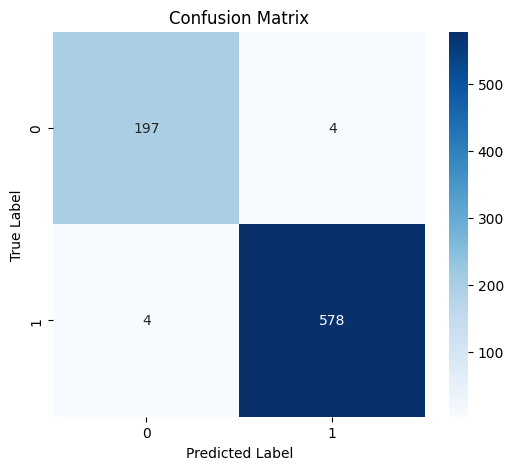

In [43]:
"""
🎯 Purpose:
Evaluate classification performance using confusion matrix.

Why important?
- Shows correct vs incorrect predictions
- Helps identify model weaknesses
"""

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig("../outputs/graphs/confusion_matrix.png")
plt.show()

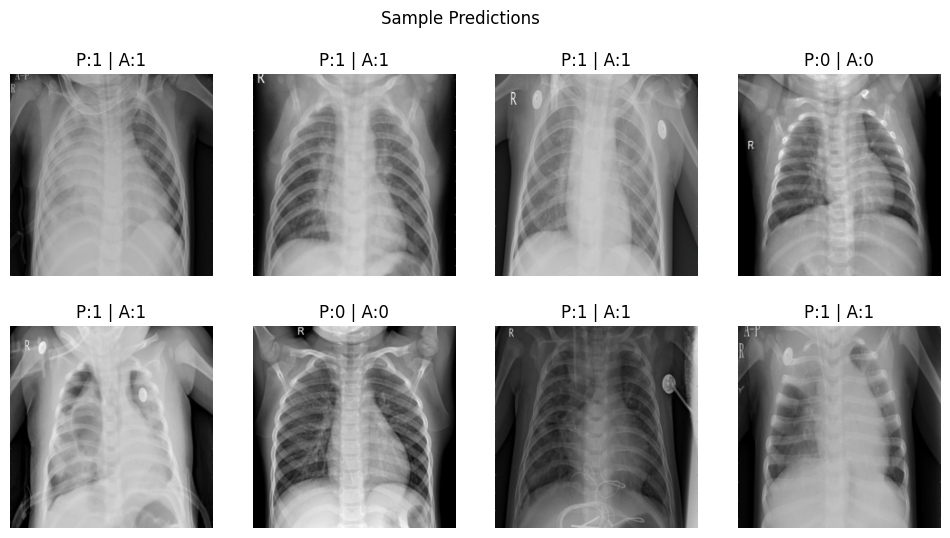

In [44]:
"""
🎯 Purpose:
Visualize model predictions on sample images.

Why important?
- Provides intuitive understanding of model performance
- Shows real predictions vs actual labels
"""

def unnormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return img * std + mean

images, labels = next(iter(test_loader))

images = images.to(device)
outputs = model(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()

plt.figure(figsize=(12,6))

for i in range(8):
    plt.subplot(2,4,i+1)
    
    img = unnormalize(images[i])
    img = img.permute(1,2,0).numpy()
    
    plt.imshow(img)
    plt.title(f"P:{preds[i].item()} | A:{labels[i].item()}")
    plt.axis("off")

plt.suptitle("Sample Predictions")

plt.savefig("../outputs/graphs/sample_predictions.png")
plt.show()

In [45]:
"""
🎯 Purpose:
Generate precision, recall, and F1-score.

Why important?
- Provides detailed performance metrics
- Evaluates class-wise performance
"""

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=["Normal", "Pneumonia"]))


Classification Report:

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98       201
   Pneumonia       0.99      0.99      0.99       582

    accuracy                           0.99       783
   macro avg       0.99      0.99      0.99       783
weighted avg       0.99      0.99      0.99       783



In [46]:
"""
🎯 Purpose:
Load the best saved model for final evaluation.

Why important?
- Ensures best performance model is used
- Avoids using last epoch (which may not be best)
"""

model.load_state_dict(torch.load("../models/best_model.pth"))
model.eval()

print("✅ Best model loaded")

✅ Best model loaded


In [47]:
"""
🎯 Purpose:
Evaluate model on test dataset.

Why important?
- Measures real-world performance
- Final metric for assignment
"""

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total

print(f"🔥 Test Accuracy: {test_acc:.2f}%")

🔥 Test Accuracy: 97.96%


In [48]:
"""
🎯 Purpose:
Save trained model for future use.

Why important?
- Allows reuse without retraining
- Useful for deployment or further testing
"""

torch.save(model.state_dict(), "../models/final_model.pth")
print("✅ Model saved successfully")

✅ Model saved successfully
